[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

# XAI Decathlon: Round 1 Individual Method Trial

In this lab, each student works with **one assigned explainability method** and tries to use it across ten explanation events.

The notebook gives you:

- Two trained target models: one tabular model and one image model.
- Ten event prompts with ready-to-use model objects, data objects, and assigned cases.
- A markdown results table to fill in as you go.
- A final model-profile prompt for summarizing what your method can and cannot support.

The notebook does **not** implement LIME, SHAP, PDP, ALE, Grad-CAM, Score-CAM, saliency, counterfactuals, or any other explanation method for you. That is the challenge.

**Estimated time:** 60-75 minutes  
**Format:** individual method trial  
**Deliverable:** a completed results table plus a short model profile


## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Edit this markdown cell as you work through the events. Keep each evidence claim short enough that someone else can understand what your method showed and why you assigned the medal.

**My assigned method:** Perturbation-based occlusion sensitivity (feature/region replacement and permutation)

| Event | Question | Medal | Evidence from my method | Limitations or notes |
|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | Gold | Permuting `debt_ratio` caused the largest mean accuracy drop, 0.029 ± 0.005 (next: `recent_late_payments`, 0.016). | Importance is model- and data-distribution-dependent; correlated features can share importance. |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Gold | Case 718 had P(high risk)=0.499. Replacing `zip_proxy=1` with 0 lowered it by 0.248; replacing 2 late payments lowered it by 0.115. | The median is a reference, not a feasible person, so this is an association-based local explanation. |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | Gold | For the marker-present circle, P(square) fell from 0.980 to 0.018 when only the corner marker was hidden (drop 0.962); hiding the shape region changed it by -0.002. | Two marker-present probes support the finding, but more counterfactual images would quantify its prevalence. |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | Gold | Forcing `debt_ratio` from 0.075 to 0.590 raised mean P(high risk) from 0.148 to 0.442. | This is an interventional average; it may evaluate implausible feature combinations. |
| 5. Compare Two Predictions | Why were two cases classified differently? | Silver | P(high risk) was 0.022 vs 0.789. The high-risk case's 6 late payments (+0.260), debt ratio 0.536 (+0.160), and `zip_proxy=1` (+0.125) explain most of the gap. | It compares each case to a median baseline, not directly to the other case, so it is useful but not a fully contrastive explanation. |
| 6. Feature Interactions | Which tabular variables work together? | Bronze | The age/debt joint grid's largest non-additive residual was only 0.013, so it found little evidence of a strong interaction for this pair. | Only one pair and one background distribution were tested; a weak residual is not proof that no interactions exist. |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Gold | The sliding occlusion heatmap for the shortcut probe concentrated on the upper-left corner; masking that marker reduced its predicted-square probability by 0.962. | Patch size and fill value affect spatial precision; saliency is not a causal proof. |
| 8. Explain a Failure | Why did the model make this mistake? | Silver | The false-negative case had true label 1 but P(high risk)=0.400. Its high debt ratio (0.724) was the main positive evidence: replacing it lowered P(high risk) by 0.248 to 0.151. | This explains evidence supporting the wrong prediction, but not why the remaining evidence failed to cross the decision threshold or why the ground truth occurred. |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Gold | No for a shape-only task: the circle probe was predicted square with 0.980 probability, but this fell to 0.018 after masking the red marker. | This does not replace calibration, subgroup, or external-validation evidence. |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | The tabular model is debt-sensitive (0.029 permutation drop; 0.148→0.442 debt profile); the image model primarily uses the red marker rather than the shape (0.962 vs -0.002 occlusion change). | This is a strong synthesis of tested reliance, but one perturbation method cannot fully reconstruct the strategy or establish causal mechanisms/fairness. |


In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6577
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0955
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.986
2,contrast_square,4,1,0,0,0.065
3,failure_case,6,0,1,1,0.980


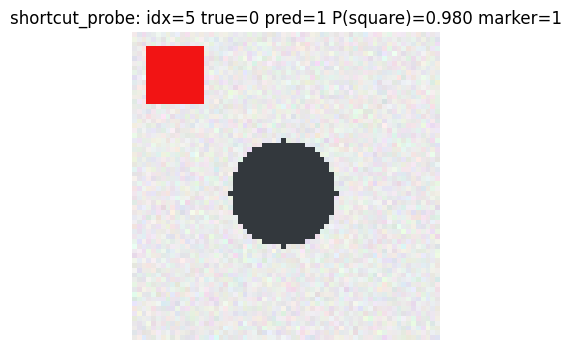

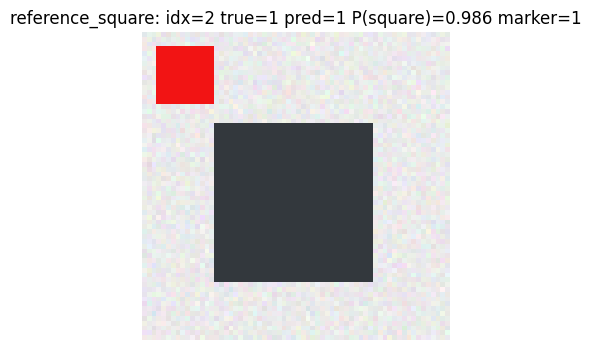

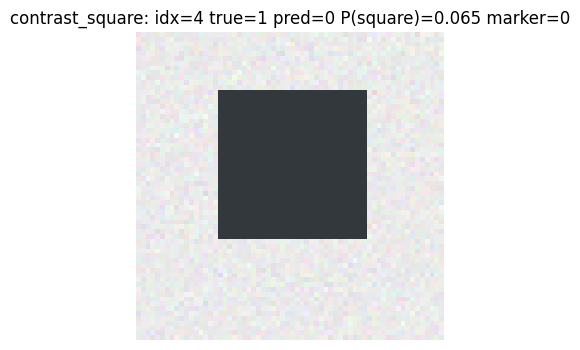

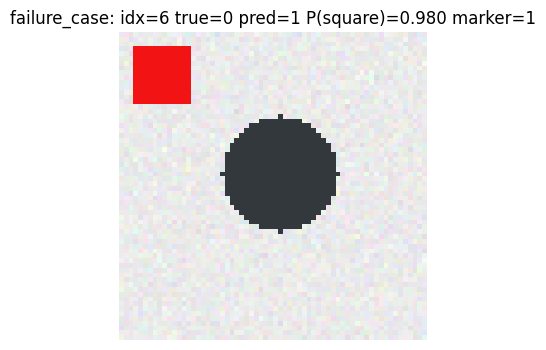

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:
# Method: perturbation-based occlusion sensitivity.
# Tabular values are replaced/reordered; image regions are covered with a neutral background.
# The explanation is the resulting change in the model probability or accuracy.

TABULAR_BASELINE = X_train.median(numeric_only=True)

def tabular_local_occlusion(row, baseline=TABULAR_BASELINE):
    """Replace one feature at a time and return the change in P(high risk)."""
    row_df = pd.DataFrame([row], columns=feature_names)
    original_p = float(predict_risk_proba(row_df)[0, 1])
    records = []
    for feature in feature_names:
        altered = row_df.copy()
        altered.loc[:, feature] = baseline[feature]
        altered_p = float(predict_risk_proba(altered)[0, 1])
        records.append({
            'feature': feature, 'case_value': float(row[feature]),
            'replacement_value': float(baseline[feature]),
            'P_high_after_replacement': altered_p,
            'effect_on_P_high': original_p - altered_p,
        })
    return original_p, pd.DataFrame(records).sort_values('effect_on_P_high', key=np.abs, ascending=False)

def tabular_permutation_importance(n_repeats=8):
    """Global occlusion: shuffle one column, then measure loss of test accuracy."""
    baseline_accuracy = accuracy_score(y_test, risk_model.predict(X_test))
    local_rng = np.random.default_rng(SEED)
    records = []
    for feature in feature_names:
        drops = []
        for _ in range(n_repeats):
            altered = X_test.copy()
            altered.loc[:, feature] = local_rng.permutation(altered[feature].to_numpy())
            drops.append(baseline_accuracy - accuracy_score(y_test, risk_model.predict(altered)))
        records.append({'feature': feature, 'accuracy_drop_mean': np.mean(drops), 'accuracy_drop_sd': np.std(drops)})
    return baseline_accuracy, pd.DataFrame(records).sort_values('accuracy_drop_mean', ascending=False)

def tabular_feature_profile(feature, n_points=16, background=X_test):
    """Controlled global feature perturbation curve using the test rows as background."""
    values = np.quantile(X_train[feature], np.linspace(.05, .95, n_points))
    means = []
    for value in values:
        altered = background.copy()
        altered.loc[:, feature] = value
        means.append(float(predict_risk_proba(altered)[:, 1].mean()))
    return pd.DataFrame({feature: values, 'mean_P_high_risk': means})

def tabular_interaction_profile(feature_a='age', feature_b='debt_ratio', n_points=7):
    """Joint occlusion grid; residual is the non-additive part of the two replacements."""
    background = X_test.sample(n=min(300, len(X_test)), random_state=SEED).copy()
    baseline_p = float(predict_risk_proba(background)[:, 1].mean())
    a_values = np.quantile(X_train[feature_a], np.linspace(.08, .92, n_points))
    b_values = np.quantile(X_train[feature_b], np.linspace(.08, .92, n_points))
    single_a, single_b = [], []
    for value in a_values:
        altered = background.copy(); altered.loc[:, feature_a] = value
        single_a.append(float(predict_risk_proba(altered)[:, 1].mean()))
    for value in b_values:
        altered = background.copy(); altered.loc[:, feature_b] = value
        single_b.append(float(predict_risk_proba(altered)[:, 1].mean()))
    joint = np.zeros((n_points, n_points))
    residual = np.zeros_like(joint)
    for i, a_value in enumerate(a_values):
        for j, b_value in enumerate(b_values):
            altered = background.copy()
            altered.loc[:, feature_a] = a_value; altered.loc[:, feature_b] = b_value
            joint[i, j] = float(predict_risk_proba(altered)[:, 1].mean())
            residual[i, j] = joint[i, j] - single_a[i] - single_b[j] + baseline_p
    return a_values, b_values, joint, residual

def occlude_image_region(image, top, left, patch=12, fill=0.92):
    altered = image.copy()
    altered[top:top + patch, left:left + patch, :] = fill
    return altered

def image_occlusion_map(idx, patch=12, stride=4, target_class=None):
    """Slide a neutral patch and record the loss in selected-class probability."""
    image = test_imgs[idx]
    original = predict_image_proba(image[None, ...])[0]
    target_class = int(original.argmax()) if target_class is None else int(target_class)
    scores = np.zeros(image.shape[:2]); counts = np.zeros(image.shape[:2])
    locations = [(top, left) for top in range(0, image.shape[0] - patch + 1, stride)
                 for left in range(0, image.shape[1] - patch + 1, stride)]
    altered_images = np.stack([occlude_image_region(image, top, left, patch) for top, left in locations])
    altered_probabilities = predict_image_proba(altered_images)[:, target_class]
    for (top, left), new_p in zip(locations, altered_probabilities):
            delta = float(original[target_class] - new_p)
            scores[top:top + patch, left:left + patch] += delta
            counts[top:top + patch, left:left + patch] += 1
    return target_class, original, np.divide(scores, counts, out=np.zeros_like(scores), where=counts != 0)

def image_region_effect(idx, top, left, patch, target_class=1):
    image = test_imgs[idx]
    before = float(predict_image_proba(image[None, ...])[0, target_class])
    after = float(predict_image_proba(occlude_image_region(image, top, left, patch)[None, ...])[0, target_class])
    return before, after, before - after

def plot_local_effects(effects, title):
    ordered = effects.sort_values('effect_on_P_high')
    plt.figure(figsize=(8, 4))
    plt.barh(ordered['feature'], ordered['effect_on_P_high'], color=np.where(ordered['effect_on_P_high'] >= 0, '#c44e52', '#4c72b0'))
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('P(high risk) before - after replacement')
    plt.title(title)
    plt.show()

print('Method ready: perturb values/regions and interpret the prediction change.')


Method ready: perturb values/regions and interpret the prediction change.


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,feature,accuracy_drop_mean,accuracy_drop_sd
2,debt_ratio,0.029,0.005
4,recent_late_payments,0.016,0.005
8,zip_proxy,0.006,0.007
1,income_k,0.004,0.004
9,promo_seen,0.004,0.003
3,loyalty_years,0.004,0.003
7,support_tickets,0.002,0.001
0,age,-0.000,0.003
6,app_minutes,-0.002,0.002
5,savings_k,-0.004,0.002


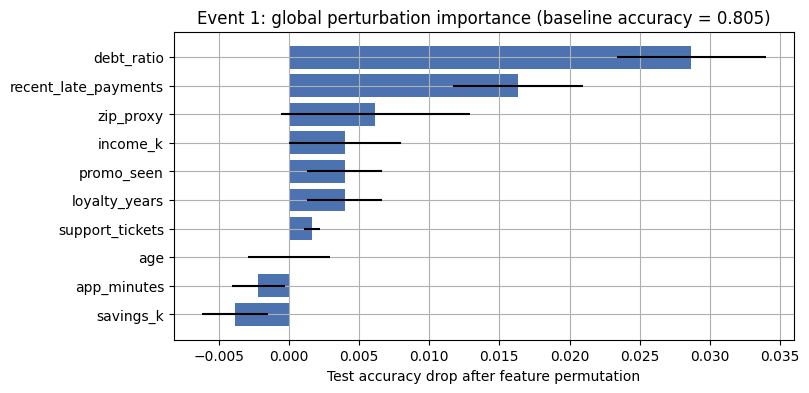

Most important by this test: debt_ratio


In [9]:
# Event 1 — global feature occlusion by permutation
baseline_accuracy, permutation_results = tabular_permutation_importance()
display(permutation_results.round(3))
plt.figure(figsize=(8, 4))
plt.barh(permutation_results['feature'][::-1], permutation_results['accuracy_drop_mean'][::-1],
         xerr=permutation_results['accuracy_drop_sd'][::-1], color='#4c72b0')
plt.xlabel('Test accuracy drop after feature permutation')
plt.title(f'Event 1: global perturbation importance (baseline accuracy = {baseline_accuracy:.3f})')
plt.show()
print('Most important by this test:', permutation_results.iloc[0]['feature'])

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Assigned local case 718: P(high risk) = 0.499


,feature,case_value,replacement_value,P_high_after_replacement,effect_on_P_high
8,zip_proxy,1.000,0.000,0.252,0.248
4,recent_late_payments,2.000,1.000,0.384,0.115
1,income_k,48.897,71.950,0.402,0.098
5,savings_k,1.147,10.575,0.441,0.059
3,loyalty_years,8.981,3.885,0.531,-0.032
0,age,38.000,47.000,0.482,0.017
6,app_minutes,13.106,17.889,0.484,0.015
2,debt_ratio,0.281,0.283,0.503,-0.003
9,promo_seen,1.000,1.000,0.499,0.000
7,support_tickets,0.000,0.000,0.499,0.000


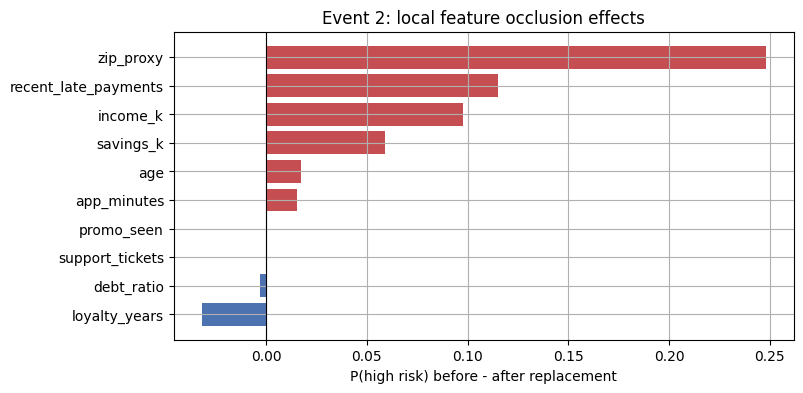

In [10]:
# Event 2 — replace each value in the assigned row with a neutral (training-median) value
local_row = X_test.iloc[tabular_local_case]
local_p, local_effects = tabular_local_occlusion(local_row)
print(f'Assigned local case {tabular_local_case}: P(high risk) = {local_p:.3f}')
display(local_effects.round(3))
plot_local_effects(local_effects, 'Event 2: local feature occlusion effects')

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,case,idx,P(square),drop after hiding marker,drop after hiding shape region
0,marker-present circle probe,5,0.980,0.962,-0.002
1,marker-present square reference,2,0.986,0.912,0.002


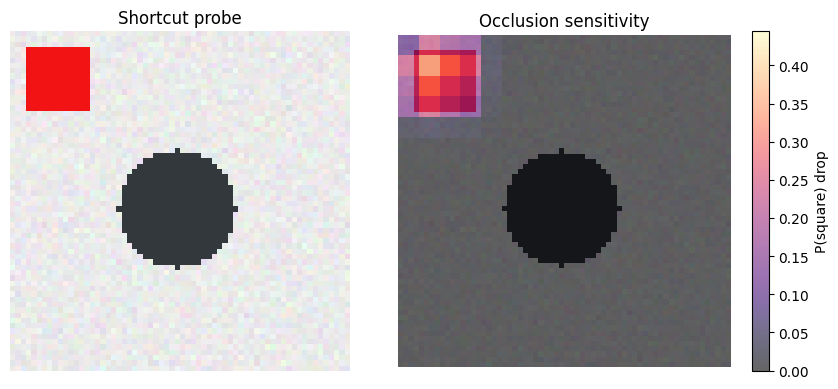

In [11]:
# Event 3 — directly hide the red corner marker and the central shape region
shortcut_checks = []
for name, idx in [('marker-present circle probe', image_shortcut_case), ('marker-present square reference', image_reference_case)]:
    marker_before, marker_after, marker_drop = image_region_effect(idx, 3, 3, 12, target_class=1)
    shape_before, shape_after, shape_drop = image_region_effect(idx, 16, 16, 32, target_class=1)
    shortcut_checks.append({'case': name, 'idx': idx, 'P(square)': marker_before,
                            'drop after hiding marker': marker_drop,
                            'drop after hiding shape region': shape_drop})
shortcut_checks = pd.DataFrame(shortcut_checks)
display(shortcut_checks.round(3))
_, _, shortcut_map = image_occlusion_map(image_shortcut_case, target_class=1)
plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1); plt.imshow(test_imgs[image_shortcut_case]); plt.axis('off'); plt.title('Shortcut probe')
plt.subplot(1, 2, 2); plt.imshow(test_imgs[image_shortcut_case]); plt.imshow(shortcut_map, cmap='magma', alpha=.60); plt.colorbar(label='P(square) drop'); plt.axis('off'); plt.title('Occlusion sensitivity')
plt.tight_layout(); plt.show()

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,debt_ratio,mean_P_high_risk
0,0.075,0.148
1,0.113,0.149
2,0.144,0.149
3,0.171,0.148
4,0.196,0.150
5,0.221,0.155
6,0.245,0.158
7,0.272,0.185
8,0.294,0.213
9,0.322,0.217


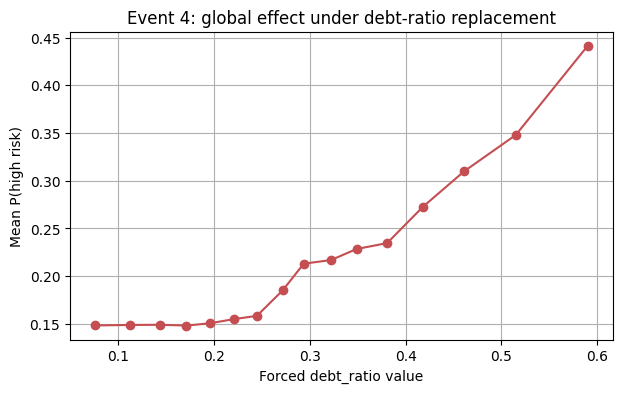

In [12]:
# Event 4 — global controlled perturbation of debt ratio
debt_profile = tabular_feature_profile('debt_ratio')
display(debt_profile.round(3))
plt.plot(debt_profile['debt_ratio'], debt_profile['mean_P_high_risk'], marker='o', color='#c44e52')
plt.xlabel('Forced debt_ratio value'); plt.ylabel('Mean P(high risk)')
plt.title('Event 4: global effect under debt-ratio replacement')
plt.show()

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Low case P(high risk)=0.022; high case P(high risk)=0.789


,feature,case_value_low_case,effect_on_P_high_low_case,case_value_high_case,effect_on_P_high_high_case,effect_gap_high_minus_low
4,recent_late_payments,0.000,-0.001,6.000,0.260,0.261
1,debt_ratio,0.044,-0.016,0.536,0.160,0.176
8,zip_proxy,0.000,0.000,1.000,0.125,0.125
0,income_k,102.549,-0.027,38.814,0.061,0.089
5,app_minutes,23.506,-0.001,23.557,-0.042,-0.041
6,age,54.000,-0.001,28.000,0.018,0.019
2,loyalty_years,21.356,-0.011,1.485,0.007,0.018
7,savings_k,18.423,-0.000,3.738,0.012,0.012
3,promo_seen,0.000,-0.007,1.000,0.000,0.007
9,support_tickets,0.000,0.000,1.000,0.006,0.006


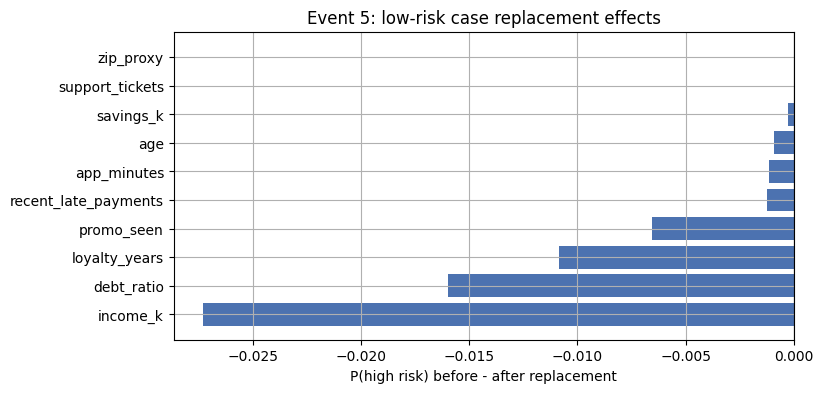

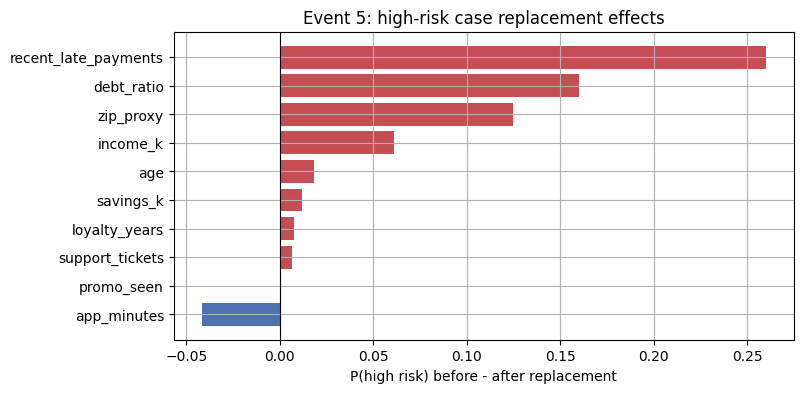

In [13]:
# Event 5 — compare the one-feature replacement effects for the low and high risk cases
low_p, low_effects = tabular_local_occlusion(X_test.iloc[tabular_low_case])
high_p, high_effects = tabular_local_occlusion(X_test.iloc[tabular_high_case])
comparison = low_effects[['feature', 'case_value', 'effect_on_P_high']].merge(
    high_effects[['feature', 'case_value', 'effect_on_P_high']], on='feature', suffixes=('_low_case', '_high_case'))
comparison['effect_gap_high_minus_low'] = comparison['effect_on_P_high_high_case'] - comparison['effect_on_P_high_low_case']
comparison = comparison.sort_values('effect_gap_high_minus_low', key=np.abs, ascending=False)
print(f'Low case P(high risk)={low_p:.3f}; high case P(high risk)={high_p:.3f}')
display(comparison.round(3))
plot_local_effects(low_effects, 'Event 5: low-risk case replacement effects')
plot_local_effects(high_effects, 'Event 5: high-risk case replacement effects')

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Largest absolute non-additive residual: 0.013


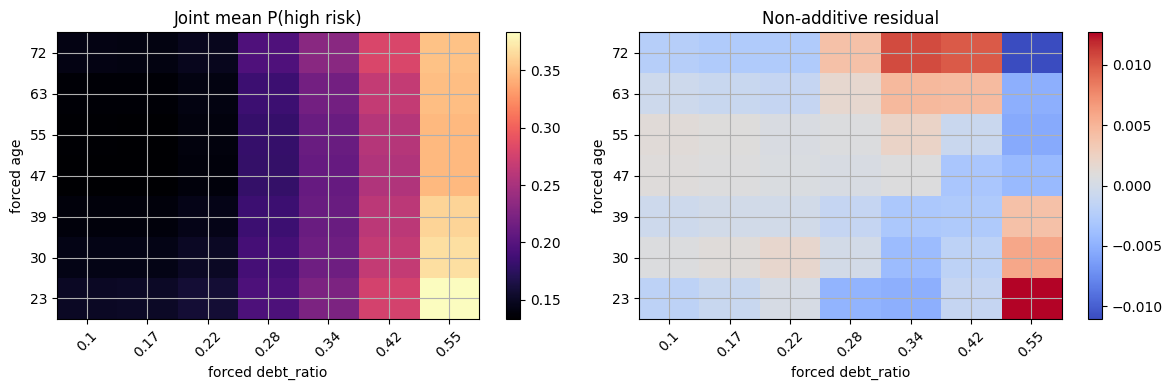

In [14]:
# Event 6 — test whether age and debt_ratio have a non-additive joint replacement effect
age_values, debt_values, joint_risk, interaction_residual = tabular_interaction_profile('age', 'debt_ratio')
print('Largest absolute non-additive residual:', round(float(np.abs(interaction_residual).max()), 3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, values, title, cmap in [(axes[0], joint_risk, 'Joint mean P(high risk)', 'magma'),
                               (axes[1], interaction_residual, 'Non-additive residual', 'coolwarm')]:
    im = ax.imshow(values, aspect='auto', origin='lower', cmap=cmap)
    ax.set_xticks(range(len(debt_values))); ax.set_xticklabels(np.round(debt_values, 2), rotation=45)
    ax.set_yticks(range(len(age_values))); ax.set_yticklabels(np.round(age_values).astype(int))
    ax.set_xlabel('forced debt_ratio'); ax.set_ylabel('forced age'); ax.set_title(title); fig.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Case 5: predicted class=1, probability=0.980


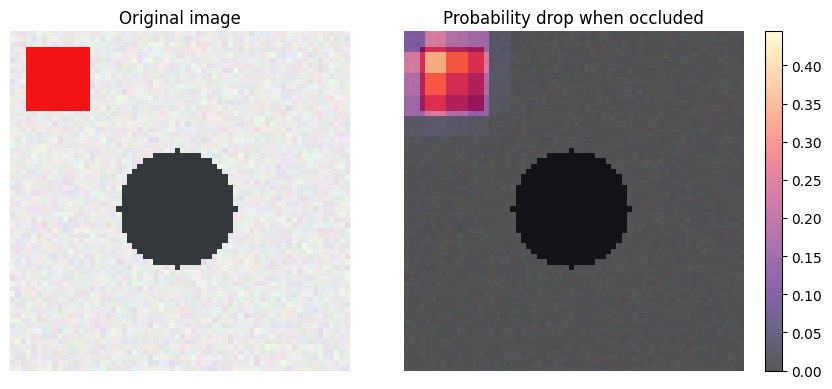

In [15]:
# Event 7 — localize evidence with a sliding occlusion map for the shortcut probe
target_class, original_probabilities, look_map = image_occlusion_map(image_shortcut_case)
print(f'Case {image_shortcut_case}: predicted class={target_class}, probability={original_probabilities[target_class]:.3f}')
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(test_imgs[image_shortcut_case]); axes[0].axis('off'); axes[0].set_title('Original image')
axes[1].imshow(test_imgs[image_shortcut_case]); heat = axes[1].imshow(look_map, cmap='magma', alpha=.65)
axes[1].axis('off'); axes[1].set_title('Probability drop when occluded'); fig.colorbar(heat, ax=axes[1])
plt.tight_layout(); plt.show()

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Failure case: 1 | true label: 1 | predicted label: 0 | P(high risk): 0.400


,feature,case_value,replacement_value,P_high_after_replacement,effect_on_P_high
2,debt_ratio,0.724,0.283,0.151,0.248
0,age,31.000,47.000,0.388,0.012
1,income_k,66.076,71.950,0.388,0.012
6,app_minutes,16.113,17.889,0.410,-0.010
3,loyalty_years,2.792,3.885,0.393,0.006
5,savings_k,5.975,10.575,0.404,-0.004
4,recent_late_payments,1.000,1.000,0.400,0.000
7,support_tickets,0.000,0.000,0.400,0.000
8,zip_proxy,0.000,0.000,0.400,0.000
9,promo_seen,1.000,1.000,0.400,0.000


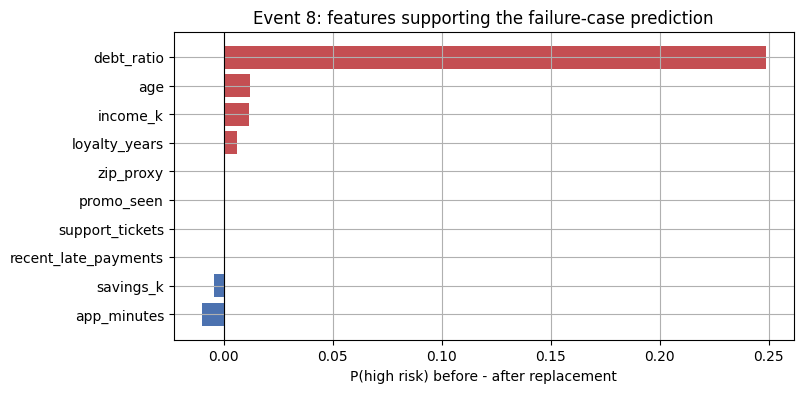

In [16]:
# Event 8 — diagnose an incorrect tabular prediction by occluding its individual values
failure_row = X_test.iloc[tabular_failure_case]
failure_p, failure_effects = tabular_local_occlusion(failure_row)
print('Failure case:', tabular_failure_case, '| true label:', int(y_test.iloc[tabular_failure_case]),
      '| predicted label:', int(tabular_pred[tabular_failure_case]), f'| P(high risk): {failure_p:.3f}')
display(failure_effects.round(3))
plot_local_effects(failure_effects, 'Event 8: features supporting the failure-case prediction')

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [17]:
# Event 9 — trust check: does the confident shortcut prediction survive removal of irrelevant corner pixels?
trust_before, trust_after_marker, trust_marker_drop = image_region_effect(image_shortcut_case, 3, 3, 12, target_class=1)
trust_before_shape, trust_after_shape, trust_shape_drop = image_region_effect(image_shortcut_case, 16, 16, 32, target_class=1)
trust_check = pd.DataFrame([{
    'case': 'marker-present circle shortcut probe', 'P(square) before': trust_before,
    'P(square) after marker hidden': trust_after_marker, 'marker sensitivity': trust_marker_drop,
    'P(square) after central shape hidden': trust_after_shape, 'shape-region sensitivity': trust_shape_drop
}])
display(trust_check.round(3))
print('Conclusion: do not trust this prediction for a shape-only decision if hiding the marker changes it substantially.')

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


,case,P(square) before,P(square) after marker hidden,marker sensitivity,P(square) after central shape hidden,shape-region sensitivity
0,marker-present circle shortcut probe,0.98,0.018,0.962,0.982,-0.002


Conclusion: do not trust this prediction for a shape-only decision if hiding the marker changes it substantially.


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

In [18]:
# Event 10 — compact synthesis of the repeated perturbation evidence
print('Tabular strategy: top global perturbation feature =', permutation_results.iloc[0]['feature'])
print('Tabular global trend: P(high risk) changes from', round(debt_profile['mean_P_high_risk'].iloc[0], 3),
      'to', round(debt_profile['mean_P_high_risk'].iloc[-1], 3), 'as forced debt_ratio increases.')
print('Image strategy: marker occlusion changes P(square) by', round(float(trust_marker_drop), 3),
      'on the shortcut probe; central-shape occlusion changes it by', round(float(trust_shape_drop), 3), '.')
print('Together these perturbations support a debt-sensitive risk model and a square prediction that uses the red-corner shortcut.')

# Useful objects you may want:
# - risk_model, X_train, X_test, y_train, y_test, feature_names, predict_risk_proba
# - tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case
# - image_model, test_imgs, test_y, test_marker, predict_image_proba, show_image_case
# - image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case

# After running your method, edit the Results Table markdown cell near the top.
# Record your medal, evidence, and limitations there.


Tabular strategy: top global perturbation feature = debt_ratio
Tabular global trend: P(high risk) changes from 0.148 to 0.442 as forced debt_ratio increases.
Image strategy: marker occlusion changes P(square) by 0.962 on the shortcut probe; central-shape occlusion changes it by -0.002 .
Together these perturbations support a debt-sensitive risk model and a square prediction that uses the red-corner shortcut.


# Final Model Profile

**Tabular model strategy:**  
I think `debt_ratio` is the most important feature in the tabular model. In Event 1, shuffling `debt_ratio` caused the largest drop in accuracy. In Event 4, when I increased `debt_ratio`, the average probability of high risk also increased. This shows a clear global effect. For the local case in Event 2, `zip_proxy` was also important because changing it had a large effect when the prediction was close to the decision boundary. I also tested the interaction between age and debt ratio, but the interaction effect was weak. My perturbation method can show which features the model relies on and how the prediction changes when I change one feature.

**Image model strategy:**  
I think the image classifier mainly depends on the red marker in the upper-left corner instead of the shape in the middle. For the circle image with a red marker, the model predicted square with a high probability. After I blocked the red marker, the probability of square dropped from 0.980 to 0.018. However, blocking the middle shape region did not change the prediction very much. This is strong evidence that the model learned the red marker as a shortcut.

**Your method's decathlon profile:**  
Perturbation-based occlusion performed well for finding important features, explaining one prediction, showing global feature effects, and checking where the image model is looking. It was especially useful for detecting the red-marker shortcut. However, it did not perform well for interaction detection because the age and debt ratio interaction was very small. This method is best for questions like: "What happens if I remove or change this feature or image region?" It is less useful for proving causality or fully explaining all model behavior.

**Open questions:**  
I would like to compare my results with classmates who used SHAP, LIME, or Grad-CAM. I want to know whether they find the same important tabular features and the same red-marker region in the image. If different methods give similar results, I would have more confidence in the conclusion.

**If you used 2 XAI approaches, how do you think your decathlon results improve?**  
If I used two XAI approaches, I could use one global approach first to identify `debt_ratio` as the highest-priority feature to explain. Then, for cases close to the decision boundary, I could use a local approach to examine features such as `zip_proxy` in more detail. This would improve the results because the global method explains the overall model behavior, while the local method explains why one specific prediction is close to high risk or low risk.

**What would still be missing after implementing both approaches together?**  
Even after using two XAI methods, we would still need human review and domain knowledge. XAI outputs can show which features or image regions influence a model, but they cannot tell us whether those features are fair, reasonable, or meaningful in the real world. Domain experts are needed to explain the results clearly to stakeholders and leadership, and to decide whether the model should be trusted or used.
